### Check results failed count

In [12]:
import pandas as pd
import numpy as np


# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv(r'H:\Master Thesis\gitlab\ma_ronit\results\charmap_simulation_results6.csv', sep=',')

failed_count = (df['status'] == 'failed').sum()
print(f'Failed count: {failed_count}')


Failed count: 1


### Calculate mean RMSE

In [15]:
import pandas as pd
df = pd.read_csv(r'h:\Master Thesis\gitlab\ma_ronit\results\charmap_simulation_results6.csv',sep=',')

cop_mean = df['cop_given'].mean()

RMSE = 0.082
mean_RMSE = RMSE / cop_mean
print(f'mean RMSE  = {round(mean_RMSE * 100,2)} %')

mean RMSE  = 2.87 %


### Maximum and minimum efficiencies of compressors 1 and 2 using real power simulation

In [17]:
import pandas as pd
df = pd.read_csv(r'h:\Master Thesis\gitlab\ma_ronit\results\compressor_results1.csv',sep=',')

eff1_max = df['Comp1 eff'].max().round(2)
eff2_max = df['Comp2 eff'].max().round(2)
eff1_min = df['Comp1 eff'].min().round(2)
eff2_min = df['Comp2 eff'].min().round(2)
print(f"Compressor 1 max and min : {eff1_max} and {eff1_min} \nCompressor 2 max and min : {eff2_max} and {eff2_min}  ")


Compressor 1 max and min : 0.87 and 0.29 
Compressor 2 max and min : 0.78 and 0.35  


### Error metrics bar plots

  Method   RMSE  Relative RMSE (%)  MAPE (%)     R²  Sigma  NMBE (%)
0      1  0.132               4.62      2.97  0.633  0.113      1.03
1      2  0.137               4.79      3.99  0.644  0.101      0.61
2      3  0.082               2.87      2.31  0.872  0.050      0.92
3      4  0.111               3.88      3.11  0.766  0.070      1.53
4      5  0.080               2.80      1.73  0.864  0.064      0.04
5      6  0.082               2.87      1.89  0.871  0.064      0.03


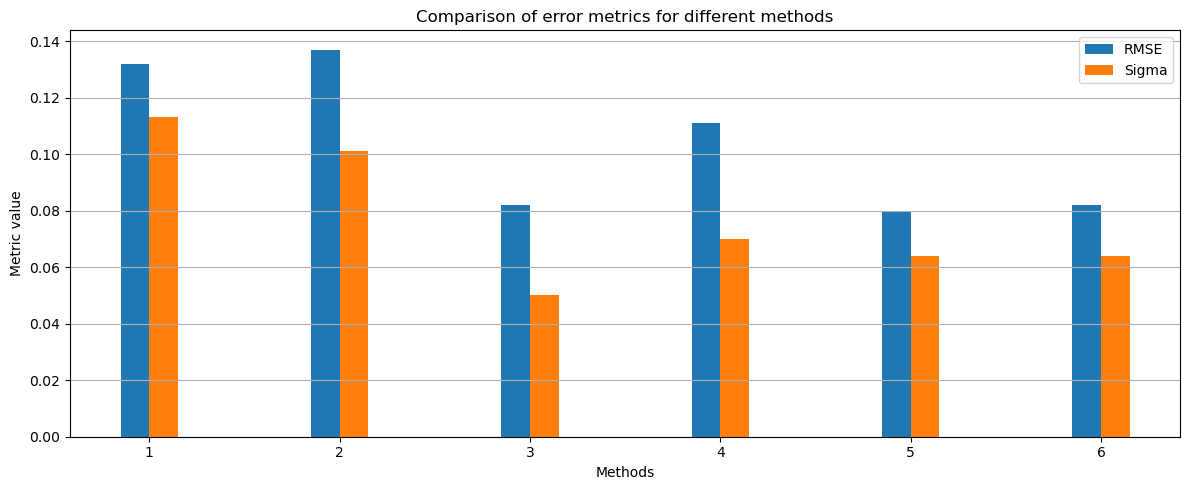

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import fhgcd_plots.main as fhgCD
import numpy as np

# Example values
df_metrics = pd.DataFrame({
    'Method': ['1', '2', '3','4','5','6'],
    'RMSE': [0.132, 0.137, 0.082,0.111,0.080,0.082],
    'Relative RMSE (%)': [4.62,4.79,2.87,3.88,2.8,2.87],
    'MAPE (%)': [2.97,3.99,2.31,3.11,1.73,1.89],
    'R²': [0.633,0.644,0.872,0.766,0.864,0.871],
    'Sigma': [0.113,0.101,0.050,0.070,0.064,0.064],
    'NMBE (%)': [1.03,0.61,0.92,1.53,0.04,0.03]
})

print(df_metrics)

#metrics_to_plot = ['Relative RMSE (%)', 'MAPE (%)',  'NMBE (%)']
metrics_to_plot = ['RMSE',  'Sigma']
#metrics_to_plot = ['R²']

x = np.arange(len(df_metrics['Method']))
width = 0.15

#fhgCD.set_matplotlib_style("darkgrid", "official")

fig, ax = plt.subplots(figsize=(12, 5))

for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i * width, df_metrics[metric], width, label=metric)

ax.set_xticks(x + width * (len(metrics_to_plot) - 1) / 2)
ax.set_xticklabels(df_metrics['Method'])
ax.set_ylabel('Metric value')
ax.set_xlabel('Methods')
ax.set_title('Comparison of error metrics for different methods')
ax.legend()
ax.grid(True, axis='y')

plt.tight_layout()
plt.show()


In [1]:
2+2

4

### Calculate second law efficiency of Heat Pump for given COP

In [47]:
import pandas as pd

df = pd.read_excel(r'H:\Master Thesis\gitlab\ma_ronit\data\process_data\Manheim_data_cleaned.xlsx', sheet_name="Mannheim_rlgwp_2025-10-22", header=0,skiprows=range(1, 5)) #Load profile data

T_sink_in = df['Column24']
T_sink_out = df['Column23']
T_source_in = df['Column27']
T_source_out = df['Column28']

T_sink_avg = (T_sink_in + T_sink_out) / 2
T_source_avg = (T_source_in + T_source_out) / 2

T_sink_K = T_sink_avg + 273.15
T_source_K = T_source_avg + 273.15

COP_carnot = T_sink_K / (T_sink_K - T_source_K)

eta_2 = df['Column4'] / COP_carnot

print(f'Maximum : {eta_2.max().round(2)}')
print(f'Minimum : {eta_2.min().round(2)}')
print(f'Mean : {eta_2.mean().round(2)}')

Maximum : 0.59
Minimum : 0.31
Mean : 0.51


### Calculate second law efficiency of Heat Pump for simulated COP

In [48]:
import pandas as pd

df = pd.read_excel(r'H:\Master Thesis\gitlab\ma_ronit\data\process_data\Manheim_data_cleaned.xlsx', sheet_name="Mannheim_rlgwp_2025-10-22", header=0,skiprows=range(1, 5)) #Load profile data
df1 = pd.read_csv(r'H:\Master Thesis\gitlab\ma_ronit\results\charmap_simulation_results6.csv',sep=',')
mask = df1['cop'].notna()

df_clean = df[mask.to_numpy()].reset_index(drop=True)
df1_clean = df1[mask].reset_index(drop=True)

T_sink_in = df_clean['Column24']
T_sink_out = df_clean['Column23']
T_source_in = df_clean['Column27']
T_source_out = df_clean['Column28']

T_sink_avg = (T_sink_in + T_sink_out) / 2
T_source_avg = (T_source_in + T_source_out) / 2

T_sink_K = T_sink_avg + 273.15
T_source_K = T_source_avg + 273.15

COP_carnot = T_sink_K / (T_sink_K - T_source_K)

eta_2 = df1_clean['cop'] / COP_carnot

print(f'Maximum : {eta_2.max().round(2)}')
print(f'Minimum : {eta_2.min().round(2)}')
print(f'Mean : {eta_2.mean().round(2)}')



Maximum : 0.56
Minimum : 0.39
Mean : 0.51


### Mean Simulated and Given COP

In [54]:
print(f'Mean simulated COP : {df1_clean['cop'].mean().round(2)}')
print(f'Mean given COP : {df_clean['Column4'].mean().round(2)}')

Mean simulated COP : 2.86
Mean given COP : 2.86
